In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.util import ngrams
from collections import Counter
import nltk
import sys
import os

# Download required NLTK data
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# Set style for plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/dylanmackown/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/dylanmackown/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/dylanmackown/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [12]:
# Load the PCL dataset
# Dynamically construct the path based on current directory
current_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else os.getcwd()
if os.path.basename(current_dir) != 'NLP-CW':
    # If running from notebook, go up to find the workspace root
    workspace_root = current_dir
else:
    workspace_root = current_dir

pcl_file = os.path.join(workspace_root, 'NLPLabs-2024', 
                        'Dont_Patronize_Me_Trainingset', 'dontpatronizeme_pcl.tsv')

# Read the TSV file, skipping the disclaimer header (first 3 lines)
df = pd.read_csv(pcl_file, sep='\t', skiprows=3, header=None)
df.columns = ['id', 'post_id', 'category', 'country', 'text', 'label']

print(f"Dataset file: {pcl_file}")
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nDataset info:")
print(df.info())
print(f"\nLabel distribution:")
print(df['label'].value_counts())

Dataset file: /Users/dylanmackown/Documents/Uni/Year3/NLP/NLP-CW/NLPLabs-2024/Dont_Patronize_Me_Trainingset/dontpatronizeme_pcl.tsv
Dataset shape: (10469, 6)

First few rows:
   id     post_id   category country  \
0   1  @@24942188   hopeless      ph   
1   2  @@21968160    migrant      gh   
2   3  @@16584954  immigrant      ie   
3   4   @@7811231   disabled      nz   
4   5   @@1494111    refugee      ca   

                                                text  label  
0  We 're living in times of absolute insanity , ...      0  
1  In Libya today , there are countless number of...      0  
2  White House press secretary Sean Spicer said t...      0  
3  Council customers only signs would be displaye...      0  
4  " Just like we received migrants fleeing El Sa...      0  

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 10469 entries, 0 to 10468
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        10469 non-n

In [6]:
# Text preprocessing function
def preprocess_text(text):
    """Tokenize and clean text"""
    # Handle NaN values
    if pd.isna(text):
        return []
    # Convert to lowercase
    text = text.lower()
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords and non-alphabetic tokens
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token.isalpha() and token not in stop_words]
    return tokens

# Preprocess all texts and extract n-grams
print("Preprocessing texts...")
all_tokens = []
unigrams_list = []
bigrams_list = []
trigrams_list = []

for text in df['text']:
    tokens = preprocess_text(text)
    all_tokens.extend(tokens)
    
    # Extract n-grams
    unigrams_list.extend(ngrams(tokens, 1))
    bigrams_list.extend(ngrams(tokens, 2))
    trigrams_list.extend(ngrams(tokens, 3))

print(f"Total tokens: {len(all_tokens)}")
print(f"Total unigrams: {len(unigrams_list)}")
print(f"Total bigrams: {len(bigrams_list)}")
print(f"Total trigrams: {len(trigrams_list)}")

# Count n-grams
unigram_counts = Counter(unigrams_list)
bigram_counts = Counter(bigrams_list)
trigram_counts = Counter(trigrams_list)

print(f"\nUnique unigrams: {len(unigram_counts)}")
print(f"Unique bigrams: {len(bigram_counts)}")
print(f"Unique trigrams: {len(trigram_counts)}")

Preprocessing texts...
Total tokens: 246081
Total unigrams: 246081
Total bigrams: 235613
Total trigrams: 225149

Unique unigrams: 28347
Unique bigrams: 195757
Unique trigrams: 219674


In [13]:
# Separate n-gram analysis: PCL vs Non-PCL
print("\n" + "="*70)
print("N-GRAM ANALYSIS: PCL vs NON-PCL TEXTS")
print("="*70)

# Separate data by PCL label (PCL: 2-5, Non-PCL: 0-1)
pcl_df = df[df['label'].isin([2, 3, 4, 5])]  # PCL texts (labels 2-5)
non_pcl_df = df[df['label'].isin([0, 1])]  # Non-PCL texts (labels 0-1)

print(f"\nPCL Documents (labels 2-5): {len(pcl_df)} ({len(pcl_df)/len(df)*100:.1f}%)")
print(f"Non-PCL Documents (labels 0-1): {len(non_pcl_df)} ({len(non_pcl_df)/len(df)*100:.1f}%)")

# Extract n-grams for PCL texts
pcl_tokens = []
pcl_unigrams = []
pcl_bigrams = []
pcl_trigrams = []

for text in pcl_df['text']:
    tokens = preprocess_text(text)
    pcl_tokens.extend(tokens)
    pcl_unigrams.extend(ngrams(tokens, 1))
    pcl_bigrams.extend(ngrams(tokens, 2))
    pcl_trigrams.extend(ngrams(tokens, 3))

# Extract n-grams for Non-PCL texts
non_pcl_tokens = []
non_pcl_unigrams = []
non_pcl_bigrams = []
non_pcl_trigrams = []

for text in non_pcl_df['text']:
    tokens = preprocess_text(text)
    non_pcl_tokens.extend(tokens)
    non_pcl_unigrams.extend(ngrams(tokens, 1))
    non_pcl_bigrams.extend(ngrams(tokens, 2))
    non_pcl_trigrams.extend(ngrams(tokens, 3))

# Count n-grams
pcl_unigram_counts = Counter(pcl_unigrams)
pcl_bigram_counts = Counter(pcl_bigrams)
pcl_trigram_counts = Counter(pcl_trigrams)

non_pcl_unigram_counts = Counter(non_pcl_unigrams)
non_pcl_bigram_counts = Counter(non_pcl_bigrams)
non_pcl_trigram_counts = Counter(non_pcl_trigrams)

print(f"\nPCL - Total tokens: {len(pcl_tokens)}")
print(f"PCL - Unique unigrams: {len(pcl_unigram_counts)}")
print(f"PCL - Unique bigrams: {len(pcl_bigram_counts)}")
print(f"PCL - Unique trigrams: {len(pcl_trigram_counts)}")

print(f"\nNon-PCL - Total tokens: {len(non_pcl_tokens)}")
print(f"Non-PCL - Unique unigrams: {len(non_pcl_unigram_counts)}")
print(f"Non-PCL - Unique bigrams: {len(non_pcl_bigram_counts)}")
print(f"Non-PCL - Unique trigrams: {len(non_pcl_trigram_counts)}")


N-GRAM ANALYSIS: PCL vs NON-PCL TEXTS

PCL Documents (labels 2-5): 993 (9.5%)
Non-PCL Documents (labels 0-1): 9476 (90.5%)

PCL - Total tokens: 24943
PCL - Unique unigrams: 7358
PCL - Unique bigrams: 22241
PCL - Unique trigrams: 22792

Non-PCL - Total tokens: 221138
Non-PCL - Unique unigrams: 26888
Non-PCL - Unique bigrams: 177280
Non-PCL - Unique trigrams: 197382


In [17]:
# Get top n-grams for PCL and Non-PCL
top_n = 15

# PCL top n-grams
pcl_top_unigrams = pcl_unigram_counts.most_common(top_n)
pcl_top_bigrams = pcl_bigram_counts.most_common(top_n)
pcl_top_trigrams = pcl_trigram_counts.most_common(top_n)

# Non-PCL top n-grams
non_pcl_top_unigrams = non_pcl_unigram_counts.most_common(top_n)
non_pcl_top_bigrams = non_pcl_bigram_counts.most_common(top_n)
non_pcl_top_trigrams = non_pcl_trigram_counts.most_common(top_n)

# Display PCL n-grams
print("\n" + "="*70)
print("TOP 15 UNIGRAMS IN PCL TEXTS")
print("="*70)
pcl_uni_df = pd.DataFrame(pcl_top_unigrams, columns=['Unigram', 'Count'])
pcl_uni_df['Unigram'] = pcl_uni_df['Unigram'].apply(lambda x: x[0])
print(pcl_uni_df.to_string(index=False))

print("\n" + "="*70)
print("TOP 15 BIGRAMS IN PCL TEXTS")
print("="*70)
pcl_bi_df = pd.DataFrame(pcl_top_bigrams, columns=['Bigram', 'Count'])
pcl_bi_df['Bigram'] = pcl_bi_df['Bigram'].apply(lambda x: ' '.join(x))
print(pcl_bi_df.to_string(index=False))

print("\n" + "="*70)
print("TOP 15 TRIGRAMS IN PCL TEXTS")
print("="*70)
pcl_tri_df = pd.DataFrame(pcl_top_trigrams, columns=['Trigram', 'Count'])
pcl_tri_df['Trigram'] = pcl_tri_df['Trigram'].apply(lambda x: ' '.join(x))
print(pcl_tri_df.to_string(index=False))

# Display Non-PCL n-grams
print("\n" + "="*70)
print("TOP 15 UNIGRAMS IN NON-PCL TEXTS")
print("="*70)
non_pcl_uni_df = pd.DataFrame(non_pcl_top_unigrams, columns=['Unigram', 'Count'])
non_pcl_uni_df['Unigram'] = non_pcl_uni_df['Unigram'].apply(lambda x: x[0])
print(non_pcl_uni_df.to_string(index=False))

print("\n" + "="*70)
print("TOP 15 BIGRAMS IN NON-PCL TEXTS")
print("="*70)
non_pcl_bi_df = pd.DataFrame(non_pcl_top_bigrams, columns=['Bigram', 'Count'])
non_pcl_bi_df['Bigram'] = non_pcl_bi_df['Bigram'].apply(lambda x: ' '.join(x))
print(non_pcl_bi_df.to_string(index=False))

print("\n" + "="*70)
print("TOP 15 TRIGRAMS IN NON-PCL TEXTS")
print("="*70)
non_pcl_tri_df = pd.DataFrame(non_pcl_top_trigrams, columns=['Trigram', 'Count'])
non_pcl_tri_df['Trigram'] = non_pcl_tri_df['Trigram'].apply(lambda x: ' '.join(x))
print(non_pcl_tri_df.to_string(index=False))


TOP 15 UNIGRAMS IN PCL TEXTS
   Unigram  Count
    people    256
      need    238
      poor    232
  families    212
  children    199
      said    194
  homeless    177
     women    144
      help    136
  disabled    104
vulnerable     97
  refugees     95
      life     93
      many     92
     would     90

TOP 15 BIGRAMS IN PCL TEXTS
            Bigram  Count
     poor families    149
       people need     29
   homeless people     26
     children poor     21
         help need     18
   disabled people     14
 vulnerable people     12
         men women     12
    women children     11
       help people     11
            let us     11
hundreds thousands     10
     hope hopeless     10
         need said      8
         sri lanka      8

TOP 15 TRIGRAMS IN PCL TEXTS
                    Trigram  Count
     children poor families     21
         come poor families      7
           help people need      4
      brought united states      4
         many poor families     

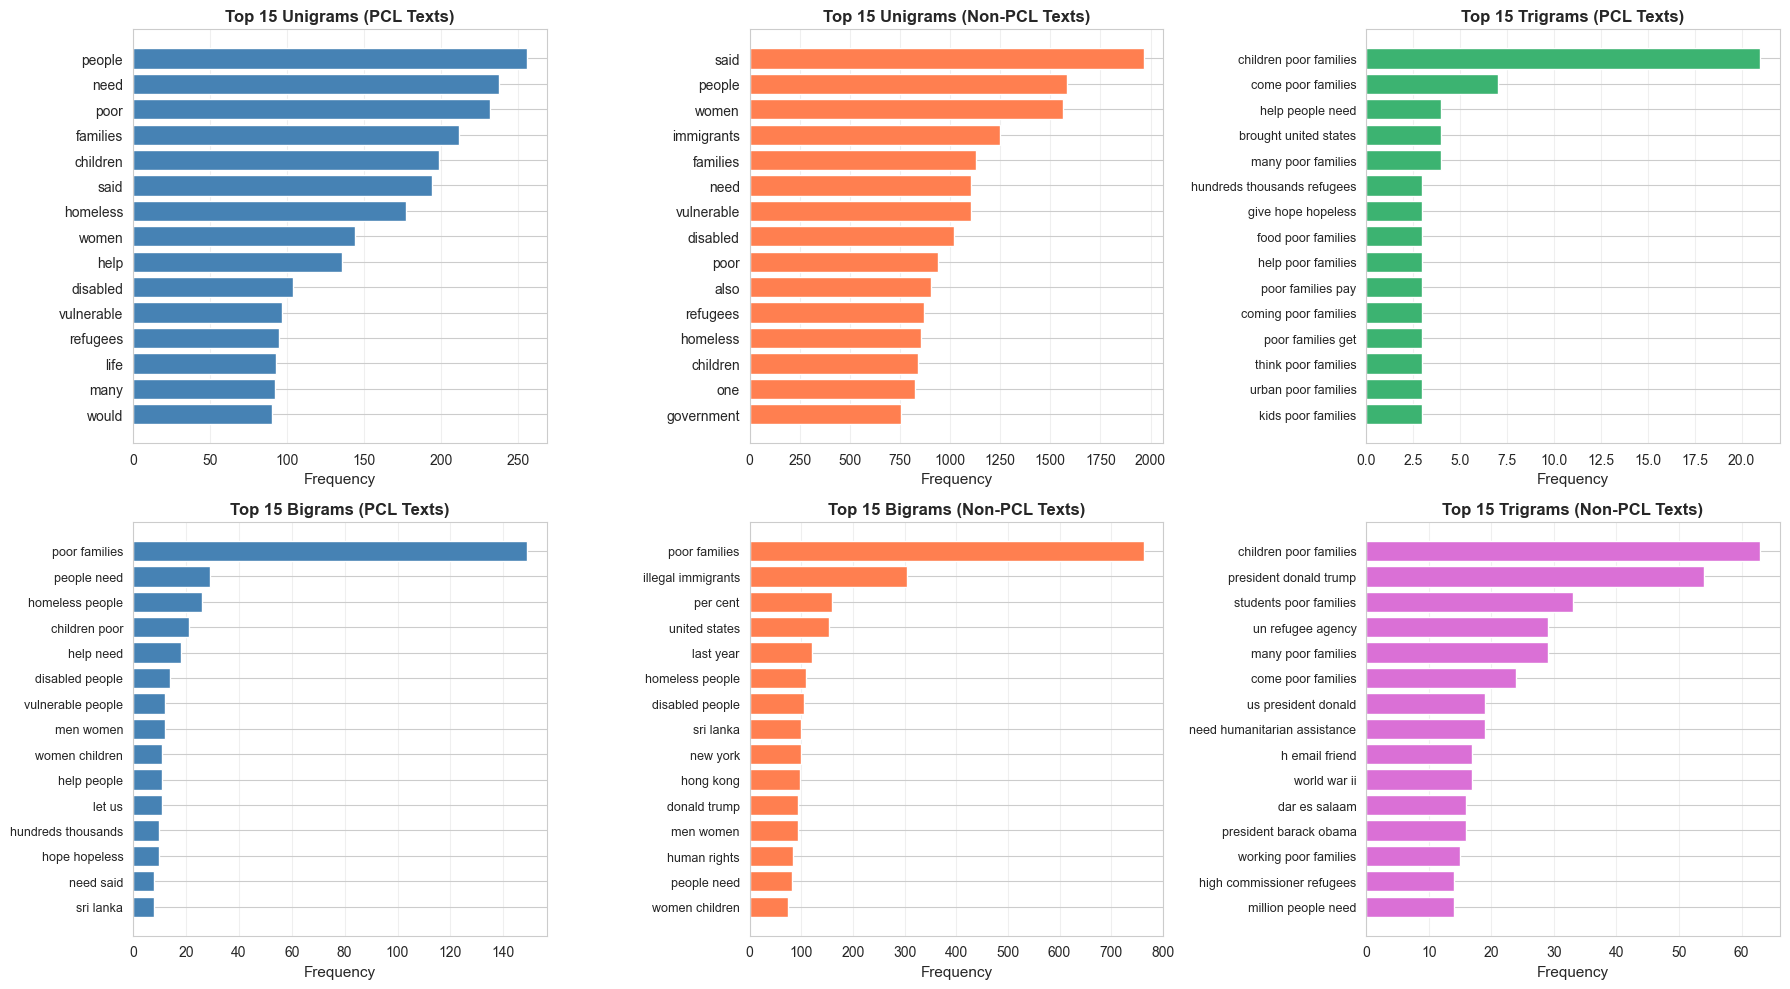

Figure saved as 'ngram_pcl_vs_non_pcl.png'


In [18]:
# Visualize PCL vs Non-PCL n-grams
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# PCL Unigrams
pcl_uni_plot = pcl_uni_df.copy()
pcl_uni_plot['Unigram'] = pcl_uni_plot['Unigram'].astype(str)
axes[0, 0].barh(range(len(pcl_uni_plot)), pcl_uni_plot['Count'], color='steelblue')
axes[0, 0].set_yticks(range(len(pcl_uni_plot)))
axes[0, 0].set_yticklabels(pcl_uni_plot['Unigram'])
axes[0, 0].invert_yaxis()
axes[0, 0].set_xlabel('Frequency', fontsize=11)
axes[0, 0].set_title('Top 15 Unigrams (PCL Texts)', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)

# Non-PCL Unigrams
non_pcl_uni_plot = non_pcl_uni_df.copy()
non_pcl_uni_plot['Unigram'] = non_pcl_uni_plot['Unigram'].astype(str)
axes[0, 1].barh(range(len(non_pcl_uni_plot)), non_pcl_uni_plot['Count'], color='coral')
axes[0, 1].set_yticks(range(len(non_pcl_uni_plot)))
axes[0, 1].set_yticklabels(non_pcl_uni_plot['Unigram'])
axes[0, 1].invert_yaxis()
axes[0, 1].set_xlabel('Frequency', fontsize=11)
axes[0, 1].set_title('Top 15 Unigrams (Non-PCL Texts)', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='x', alpha=0.3)

# PCL Trigrams
pcl_tri_plot = pcl_tri_df.copy()
pcl_tri_plot['Trigram'] = pcl_tri_plot['Trigram'].astype(str)
axes[0, 2].barh(range(len(pcl_tri_plot)), pcl_tri_plot['Count'], color='mediumseagreen')
axes[0, 2].set_yticks(range(len(pcl_tri_plot)))
axes[0, 2].set_yticklabels(pcl_tri_plot['Trigram'], fontsize=9)
axes[0, 2].invert_yaxis()
axes[0, 2].set_xlabel('Frequency', fontsize=11)
axes[0, 2].set_title('Top 15 Trigrams (PCL Texts)', fontsize=12, fontweight='bold')
axes[0, 2].grid(axis='x', alpha=0.3)

# PCL Bigrams
axes[1, 0].barh(range(len(pcl_bi_df)), pcl_bi_df['Count'], color='steelblue')
axes[1, 0].set_yticks(range(len(pcl_bi_df)))
axes[1, 0].set_yticklabels(pcl_bi_df['Bigram'], fontsize=9)
axes[1, 0].invert_yaxis()
axes[1, 0].set_xlabel('Frequency', fontsize=11)
axes[1, 0].set_title('Top 15 Bigrams (PCL Texts)', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)

# Non-PCL Bigrams
axes[1, 1].barh(range(len(non_pcl_bi_df)), non_pcl_bi_df['Count'], color='coral')
axes[1, 1].set_yticks(range(len(non_pcl_bi_df)))
axes[1, 1].set_yticklabels(non_pcl_bi_df['Bigram'], fontsize=9)
axes[1, 1].invert_yaxis()
axes[1, 1].set_xlabel('Frequency', fontsize=11)
axes[1, 1].set_title('Top 15 Bigrams (Non-PCL Texts)', fontsize=12, fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)

# Non-PCL Trigrams
non_pcl_tri_plot = non_pcl_tri_df.copy()
non_pcl_tri_plot['Trigram'] = non_pcl_tri_plot['Trigram'].astype(str)
axes[1, 2].barh(range(len(non_pcl_tri_plot)), non_pcl_tri_plot['Count'], color='orchid')
axes[1, 2].set_yticks(range(len(non_pcl_tri_plot)))
axes[1, 2].set_yticklabels(non_pcl_tri_plot['Trigram'], fontsize=9)
axes[1, 2].invert_yaxis()
axes[1, 2].set_xlabel('Frequency', fontsize=11)
axes[1, 2].set_title('Top 15 Trigrams (Non-PCL Texts)', fontsize=12, fontweight='bold')
axes[1, 2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('ngram_pcl_vs_non_pcl.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved as 'ngram_pcl_vs_non_pcl.png'")

In [16]:
# Summary statistics: PCL vs Non-PCL
print("\n" + "="*70)
print("SUMMARY STATISTICS: PCL vs NON-PCL")
print("="*70)

comparison_stats = {
    'Metric': [
        'Documents',
        'Total Tokens',
        'Average Tokens/Doc',
        'Unique Unigrams',
        'Unique Bigrams',
        'Unique Trigrams',
        'Type-Token Ratio'
    ],
    'PCL': [
        len(pcl_df),
        len(pcl_tokens),
        round(len(pcl_tokens) / len(pcl_df), 2) if len(pcl_df) > 0 else 0,
        len(pcl_unigram_counts),
        len(pcl_bigram_counts),
        len(pcl_trigram_counts),
        round(len(pcl_unigram_counts) / len(pcl_tokens), 4) if len(pcl_tokens) > 0 else 0
    ],
    'Non-PCL': [
        len(non_pcl_df),
        len(non_pcl_tokens),
        round(len(non_pcl_tokens) / len(non_pcl_df), 2) if len(non_pcl_df) > 0 else 0,
        len(non_pcl_unigram_counts),
        len(non_pcl_bigram_counts),
        len(non_pcl_trigram_counts),
        round(len(non_pcl_unigram_counts) / len(non_pcl_tokens), 4) if len(non_pcl_tokens) > 0 else 0
    ]
}

comparison_df = pd.DataFrame(comparison_stats)
print(comparison_df.to_string(index=False))

# Find commonalities and differences
print("\n" + "="*70)
print("COMMON UNIGRAMS BETWEEN PCL AND NON-PCL")
print("="*70)
pcl_unigram_set = set([ngram for ngram, _ in pcl_top_unigrams])
non_pcl_unigram_set = set([ngram for ngram, _ in non_pcl_top_unigrams])
common_unigrams = pcl_unigram_set & non_pcl_unigram_set
print(f"Common top unigrams: {len(common_unigrams)}")
for uni in sorted(common_unigrams):
    print(f"  - {uni[0]}")

print("\n" + "="*70)
print("UNIQUE UNIGRAMS IN PCL (NOT IN TOP 15 NON-PCL)")
print("="*70)
unique_to_pcl = pcl_unigram_set - non_pcl_unigram_set
for uni in sorted(unique_to_pcl):
    print(f"  - {uni[0]}")

print("\n" + "="*70)
print("UNIQUE UNIGRAMS IN NON-PCL (NOT IN TOP 15 PCL)")
print("="*70)
unique_to_non_pcl = non_pcl_unigram_set - pcl_unigram_set
for uni in sorted(unique_to_non_pcl):
    print(f"  - {uni[0]}")


SUMMARY STATISTICS: PCL vs NON-PCL
            Metric       PCL     Non-PCL
         Documents   993.000   9476.0000
      Total Tokens 24943.000 221138.0000
Average Tokens/Doc    25.120     23.3400
   Unique Unigrams  7358.000  26888.0000
    Unique Bigrams 22241.000 177280.0000
   Unique Trigrams 22792.000 197382.0000
  Type-Token Ratio     0.295      0.1216

COMMON UNIGRAMS BETWEEN PCL AND NON-PCL
Common top unigrams: 11
  - children
  - disabled
  - families
  - homeless
  - need
  - people
  - poor
  - refugees
  - said
  - vulnerable
  - women

UNIQUE UNIGRAMS IN PCL (NOT IN TOP 15 NON-PCL)
  - help
  - life
  - many
  - would

UNIQUE UNIGRAMS IN NON-PCL (NOT IN TOP 15 PCL)
  - also
  - government
  - immigrants
  - one


In [19]:
# Token Count Analysis: Sentence Length for PCL vs Non-PCL
print("\n" + "="*70)
print("TOKEN COUNT ANALYSIS: SENTENCE LENGTH METRICS")
print("="*70)

# Function to calculate sentence lengths
def get_sentence_lengths(texts):
    """Calculate token count per sentence"""
    sentence_lengths = []
    for text in texts:
        if pd.isna(text):
            continue
        # Split by sentence-ending punctuation
        sentences = [s.strip() for s in text.split('. ') if s.strip()]
        # Also handle other sentence endings
        sentences = []
        temp_text = text
        for sep in ['. ', '! ', '? ', '\n']:
            parts = temp_text.split(sep)
            sentences.extend([p.strip() for p in parts if p.strip()])
        
        # Calculate token count per sentence
        for sentence in sentences:
            tokens = preprocess_text(sentence)
            if len(tokens) > 0:  # Only count non-empty sentences
                sentence_lengths.append(len(tokens))
    
    return sentence_lengths

# Calculate sentence lengths
pcl_sentence_lengths = get_sentence_lengths(pcl_df['text'].values)
non_pcl_sentence_lengths = get_sentence_lengths(non_pcl_df['text'].values)

# Calculate statistics
pcl_avg = np.mean(pcl_sentence_lengths) if pcl_sentence_lengths else 0
pcl_min = min(pcl_sentence_lengths) if pcl_sentence_lengths else 0
pcl_max = max(pcl_sentence_lengths) if pcl_sentence_lengths else 0
pcl_median = np.median(pcl_sentence_lengths) if pcl_sentence_lengths else 0
pcl_std = np.std(pcl_sentence_lengths) if pcl_sentence_lengths else 0

non_pcl_avg = np.mean(non_pcl_sentence_lengths) if non_pcl_sentence_lengths else 0
non_pcl_min = min(non_pcl_sentence_lengths) if non_pcl_sentence_lengths else 0
non_pcl_max = max(non_pcl_sentence_lengths) if non_pcl_sentence_lengths else 0
non_pcl_median = np.median(non_pcl_sentence_lengths) if non_pcl_sentence_lengths else 0
non_pcl_std = np.std(non_pcl_sentence_lengths) if non_pcl_sentence_lengths else 0

# Display results
print(f"\nPCL SENTENCE LENGTH STATISTICS:")
print(f"  Average:  {pcl_avg:.2f}")
print(f"  Minimum:  {pcl_min}")
print(f"  Maximum:  {pcl_max}")
print(f"  Median:   {pcl_median:.2f}")
print(f"  Std Dev:  {pcl_std:.2f}")
print(f"  Total sentences: {len(pcl_sentence_lengths)}")

print(f"\nNON-PCL SENTENCE LENGTH STATISTICS:")
print(f"  Average:  {non_pcl_avg:.2f}")
print(f"  Minimum:  {non_pcl_min}")
print(f"  Maximum:  {non_pcl_max}")
print(f"  Median:   {non_pcl_median:.2f}")
print(f"  Std Dev:  {non_pcl_std:.2f}")
print(f"  Total sentences: {len(non_pcl_sentence_lengths)}")


TOKEN COUNT ANALYSIS: SENTENCE LENGTH METRICS

PCL SENTENCE LENGTH STATISTICS:
  Average:  19.23
  Minimum:  1
  Maximum:  247
  Median:   17.00
  Std Dev:  14.03
  Total sentences: 5189

NON-PCL SENTENCE LENGTH STATISTICS:
  Average:  18.76
  Minimum:  1
  Maximum:  497
  Median:   17.00
  Std Dev:  12.74
  Total sentences: 47153


/var/folders/8_/8d286b4977n8bc2z8mnb8khr0000gn/T/ipykernel_62591/479549907.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0, 2].boxplot(box_data, labels=['PCL', 'Non-PCL'], patch_artist=True)


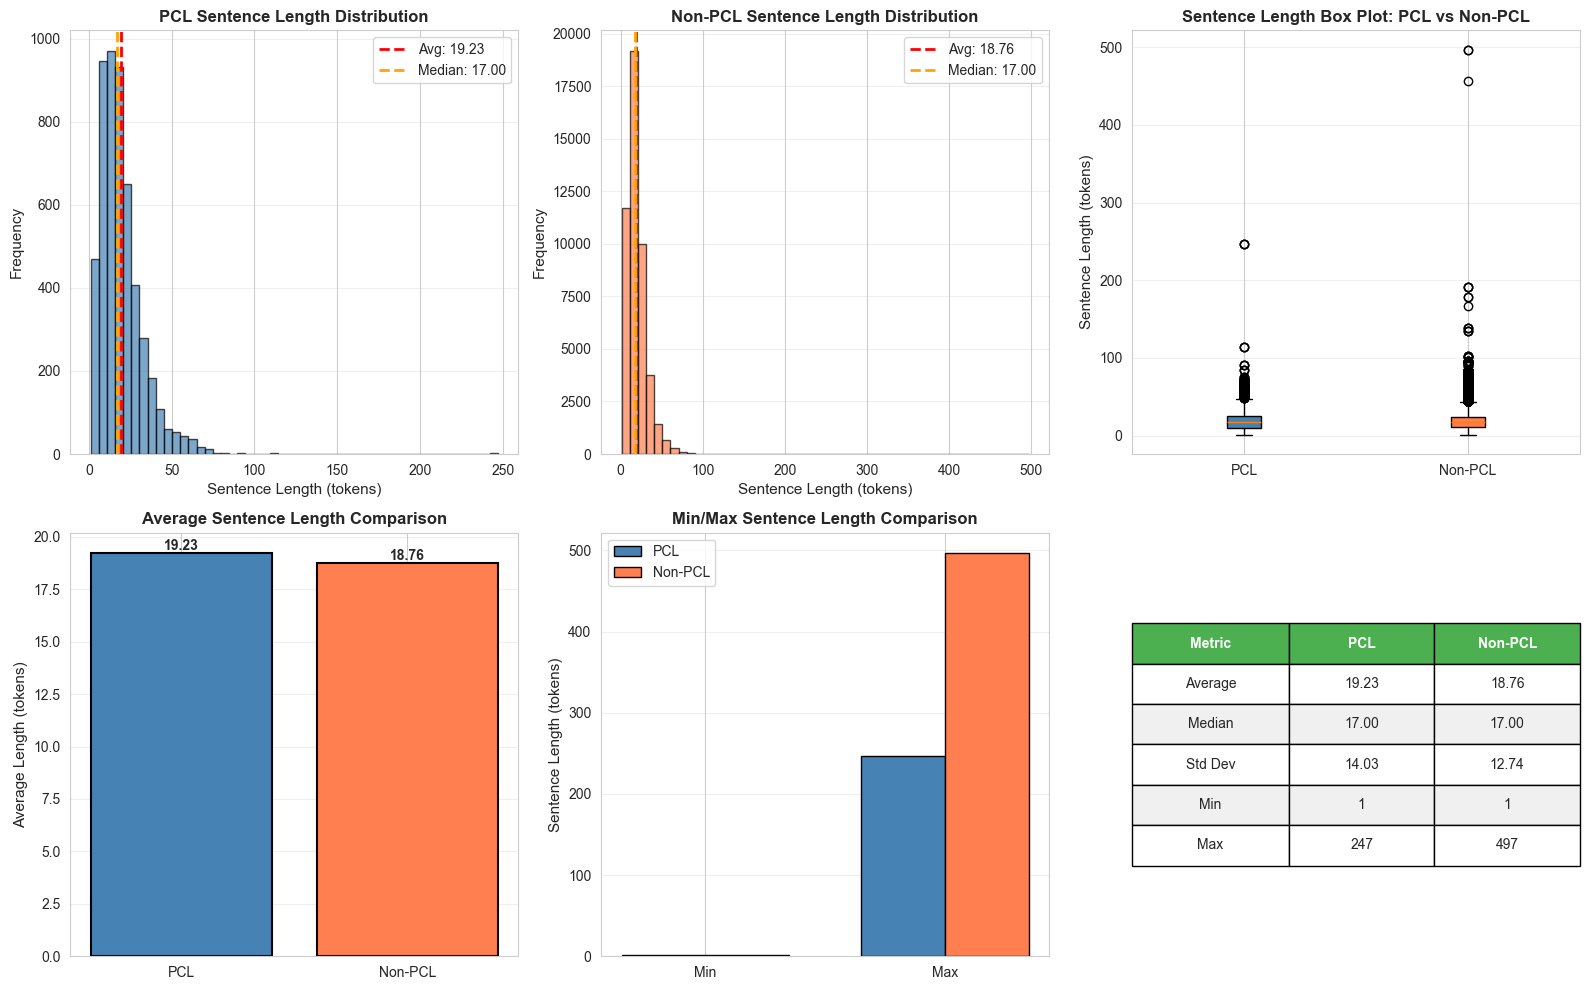


Figure saved as 'sentence_length_analysis.png'


In [20]:
# Visualize sentence length distributions and statistics
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# PCL sentence length distribution
axes[0, 0].hist(pcl_sentence_lengths, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(pcl_avg, color='red', linestyle='--', linewidth=2, label=f'Avg: {pcl_avg:.2f}')
axes[0, 0].axvline(pcl_median, color='orange', linestyle='--', linewidth=2, label=f'Median: {pcl_median:.2f}')
axes[0, 0].set_xlabel('Sentence Length (tokens)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('PCL Sentence Length Distribution', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# Non-PCL sentence length distribution
axes[0, 1].hist(non_pcl_sentence_lengths, bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(non_pcl_avg, color='red', linestyle='--', linewidth=2, label=f'Avg: {non_pcl_avg:.2f}')
axes[0, 1].axvline(non_pcl_median, color='orange', linestyle='--', linewidth=2, label=f'Median: {non_pcl_median:.2f}')
axes[0, 1].set_xlabel('Sentence Length (tokens)', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Non-PCL Sentence Length Distribution', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# Box plot comparison
box_data = [pcl_sentence_lengths, non_pcl_sentence_lengths]
bp = axes[0, 2].boxplot(box_data, labels=['PCL', 'Non-PCL'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['steelblue', 'coral']):
    patch.set_facecolor(color)
axes[0, 2].set_ylabel('Sentence Length (tokens)', fontsize=11)
axes[0, 2].set_title('Sentence Length Box Plot: PCL vs Non-PCL', fontsize=12, fontweight='bold')
axes[0, 2].grid(axis='y', alpha=0.3)

# Average sentence length comparison
avg_data = [pcl_avg, non_pcl_avg]
axes[1, 0].bar(['PCL', 'Non-PCL'], avg_data, color=['steelblue', 'coral'], edgecolor='black', linewidth=1.5)
axes[1, 0].set_ylabel('Average Length (tokens)', fontsize=11)
axes[1, 0].set_title('Average Sentence Length Comparison', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(avg_data):
    axes[1, 0].text(i, v, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')

# Min-Max comparison
metrics = ['Min', 'Max']
pcl_vals = [pcl_min, pcl_max]
non_pcl_vals = [non_pcl_min, non_pcl_max]
x = np.arange(len(metrics))
width = 0.35
axes[1, 1].bar(x - width/2, pcl_vals, width, label='PCL', color='steelblue', edgecolor='black')
axes[1, 1].bar(x + width/2, non_pcl_vals, width, label='Non-PCL', color='coral', edgecolor='black')
axes[1, 1].set_ylabel('Sentence Length (tokens)', fontsize=11)
axes[1, 1].set_title('Min/Max Sentence Length Comparison', fontsize=12, fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(metrics)
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

# Statistics table
stats_labels = ['Average', 'Median', 'Std Dev', 'Min', 'Max']
stats_pcl = [pcl_avg, pcl_median, pcl_std, pcl_min, pcl_max]
stats_non_pcl = [non_pcl_avg, non_pcl_median, non_pcl_std, non_pcl_min, non_pcl_max]

table_data = []
for i, label in enumerate(stats_labels):
    table_data.append([label, f'{stats_pcl[i]:.2f}' if isinstance(stats_pcl[i], float) else stats_pcl[i], 
                      f'{stats_non_pcl[i]:.2f}' if isinstance(stats_non_pcl[i], float) else stats_non_pcl[i]])

axes[1, 2].axis('tight')
axes[1, 2].axis('off')
table = axes[1, 2].table(cellText=table_data, colLabels=['Metric', 'PCL', 'Non-PCL'],
                         cellLoc='center', loc='center', colWidths=[0.35, 0.325, 0.325])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)
# Style header
for i in range(3):
    table[(0, i)].set_facecolor('#4CAF50')
    table[(0, i)].set_text_props(weight='bold', color='white')
# Alternate row colors
for i in range(1, len(stats_labels) + 1):
    for j in range(3):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#f0f0f0')

plt.tight_layout()
plt.savefig('sentence_length_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFigure saved as 'sentence_length_analysis.png'")

## Sentence Length Analysis: PCL vs Non-PCL

Sentence lengths are nearly identical between PCL and Non-PCL texts (average ~19 tokens, median 17 tokens). This consistency means sentence length alone is not useful for classification. However, PCL shows slightly higher variance (standard deviation 14.03 vs 12.74), suggesting a mix of very short emphatic statements alongside longer explanatory passages, whereas Non-PCL maintains more consistent sentence pacing.

The maximum sentence lengths differ—PCL peaks at 247 tokens while Non-PCL reaches 497 tokens—suggesting Non-PCL includes longer factual or quoted content, while PCL authors tend to be more concise even when elaborating.

## Impact on Classification Model

Since sentence length metrics are nearly identical between PCL and Non-PCL, they should not be primary classification features. Instead, focus on the features which show clear differences. Sentence length variance could be a weak supplementary signal, but the real discriminative power lies in what is being said, not how long the sentences are.

## N-gram Analysis: PCL vs Non-PCL

PCL texts use notably richer and more diverse vocabulary (Type-Token Ratio: 0.295 vs 0.1216 for Non-PCL), suggesting more elaborate descriptive language when discussing vulnerable populations. The most frequent unigrams in PCL (*people*, *need*, *poor*, *families*) emphasize action and assistance, while Non-PCL relies on factual language (*said*, *immigrants*, *also*) typical of news reporting.

Key phrase patterns differ between the two: PCL frequently combines vulnerable group terms with action verbs—"poor families," "people need," "help need"—reflecting a prescriptive tone. Non-PCL includes more geopolitical references and proper nouns, creating a more neutral, reported tone.

Interestingly, both classes use similar basic vocabulary about vulnerable populations (*poor*, *families*, *homeless*, *refugees*), but PCL-specific words like *help*, *would*, and *life* suggest more hopeful and prescriptive framing, whereas Non-PCL maintains journalistic neutrality.

## Impact on Classification Model

For PCL classification, bigram and trigram features are more useful than single words—particularly patterns that combine action verbs with vulnerable group references. Class imbalance (9.5% PCL) is manageable because these linguistic patterns are quite distinctive. Linear models with TF-IDF weighting and emphasis on bigrams/trigrams should work well, while neural models can benefit from attention mechanisms over n-gram sequences.

The core insight is that PCL detection hinges on *how* vulnerable populations are discussed (prescriptive tone, action-oriented language) rather than *whether* they're mentioned. Effective features should capture the pairing of vulnerable groups with assistance/action verbs, and potentially include derived features like sentence length variance and word elaboration patterns.